In [ ]:
#FasterRCNN_Resnet50

In [1]:
from ultralytics import YOLO
import cv2

model = YOLO("yolo26n.pt")
image = '../data/000000000036.jpg'


image 1/1 /home/andrey/repositories/object_detection_sketch/tests/../data/000000000036.jpg: 640x512 1 person, 1 umbrella, 35.5ms
Speed: 1.6ms preprocess, 35.5ms inference, 6.3ms postprocess per image at shape (1, 3, 640, 512)


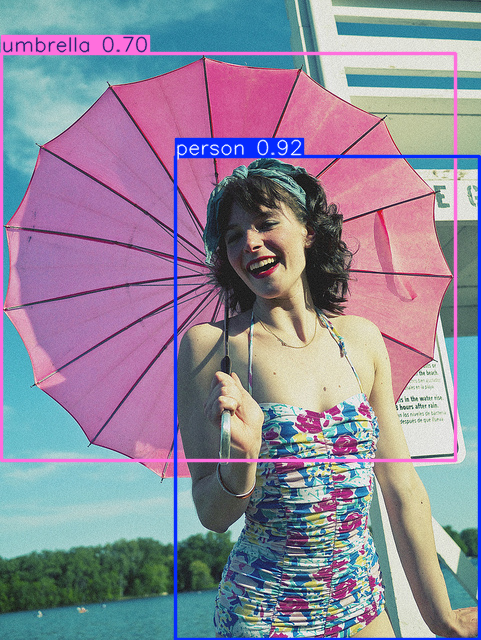

In [2]:
# Run detection on the given image
results = model.predict(image)

# Show results
results[0].show()


In [3]:
for result in results:
    xywh = result.boxes.xywh  # center-x, center-y, width, height
    xywhn = result.boxes.xywhn  # normalized
    xyxy = result.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
    xyxyn = result.boxes.xyxyn  # normalized
    names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
    confs = result.boxes.conf  # confidence score of each box


In [33]:
import torchvision
import torch
import cv2
from PIL import Image

class FRCNN():
    def __init__(self,):
        self.model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
        self.model.eval()
    

    def transform(self, frame):
        # image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image_tensor = torchvision.transforms.functional.to_tensor(frame)
        return image_tensor
    
    def make_prediction(self, frame):
        image_tensor = self.transform(frame)
        with torch.no_grad():
            predictions = self.model([image_tensor])
        
        # Визуализация результатов
        boxes = predictions[0]['boxes']
        scores = predictions[0]['scores']
        labels = predictions[0]['labels']

        return boxes, scores, labels
    


In [34]:
model = FRCNN()

image_path = 'pexels-vanyaoboleninov-237637.jpg'

image = Image.open(image_path).convert("RGB")

d:\Projects\object_detection_sketch\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Projects\object_detection_sketch\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [22]:
# cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [35]:
model.make_prediction(image)

(tensor([[2200.7935,  413.1760, 4157.0664, 2748.2783],
         [   0.0000,    0.0000, 4821.1221,  901.8498],
         [ 190.6681,    0.0000, 2664.6321,  860.0964],
         [2117.2344,  355.9795, 2283.6482,  722.5169],
         [ 109.8547,   42.2682, 4134.9927, 2412.9583],
         [1526.5874,   35.6340, 4782.1606, 1410.3696],
         [4041.8696, 1125.7145, 4191.6631, 1435.4556],
         [ 187.2665,   59.7242, 3042.0767, 1396.1786],
         [2692.6348,    0.0000, 4784.7505,  803.6199],
         [2379.9524, 1395.1632, 2745.0435, 2685.4756],
         [2357.2625, 1428.4741, 2773.5217, 2739.7351],
         [2418.0801, 1305.6875, 2606.1968, 2686.1653],
         [2311.0527,  775.9985, 2707.0161, 2352.2051],
         [2424.6775,  921.9849, 2666.3562, 1924.6511],
         [2382.1079, 1512.9910, 2722.7532, 2687.6086],
         [2374.6616, 1560.1398, 2741.2024, 2689.2168],
         [2634.7178,   72.4313, 4860.4526, 2234.2810],
         [2414.2463, 1341.8499, 2606.9783, 2719.0405]]),
 tensor(

In [4]:
result.boxes.cls.int()

tensor([ 0, 25], device='cuda:0', dtype=torch.int32)

In [ ]:


# Использование
results = model(image)
target_classes = [0, 25]  # только люди и машины
output_img = draw_specific_classes(results, target_classes)
cv2.imwrite('filtered_output.jpg', output_img)
cv2.imshow('img',output_img)


image 1/1 /home/andrey/repositories/object_detection_sketch/tests/../data/000000000036.jpg: 640x512 1 person, 1 umbrella, 52.8ms
Speed: 3.8ms preprocess, 52.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 512)


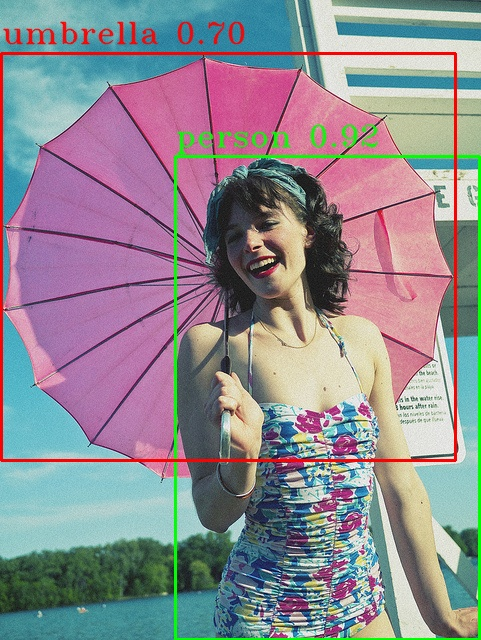

In [33]:
from IPython.display import Image, display

display(Image('filtered_output.jpg', width=300))


In [34]:
video_path = '/home/andrey/repositories/object_detection_sketch/data/videos/crowd.mp4'


cap = cv2.VideoCapture(video_path)

In [2]:
import cv2
import torch
import torchvision
import numpy as np

def real_time_detection(video_path):
    # Загружаем модель
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    model.eval()
    
    # Открываем веб-камеру
    cap = cv2.VideoCapture(video_path)
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Преобразуем кадр
        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image_tensor = torchvision.transforms.functional.to_tensor(image_rgb)
        
        # Детекция
        with torch.no_grad():
            predictions = model([image_tensor])
        
        # Визуализация результатов
        boxes = predictions[0]['boxes']
        scores = predictions[0]['scores']
        labels = predictions[0]['labels']
        
        for box, score, label in zip(boxes, scores, labels):
            if score > 0.5:
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(frame, f"{COCO_CLASSES[label]}: {score:.2f}",
                          (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
        cv2.imshow('Faster R-CNN Object Detection', frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()

In [19]:
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella',
    'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard',
    'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup',
    'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote',
    'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
    'refrigerator', 'N/A', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]

In [3]:
real_time_detection('../crowd.mp4')

d:\Projects\object_detection_sketch\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Projects\object_detection_sketch\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


NameError: name 'COCO_CLASSES' is not defined

In [4]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

In [10]:
transform = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
    ])

image_tensor = transform(image)

In [13]:
model.eval()
with torch.no_grad():
        predictions = model([image_tensor])

In [15]:
boxes = predictions[0]['boxes']
scores = predictions[0]['scores']
labels = predictions[0]['labels']

In [21]:
def visualize_detections(image, boxes, scores, labels):
    # Конвертируем PIL в numpy для OpenCV
    image_np = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    
    # Рисуем боксы
    for box, score, label in zip(boxes, scores, labels):
        if score > 0.5:  # порог уверенности
            x1, y1, x2, y2 = box.int().tolist()
            class_name = COCO_CLASSES[label]
            
            # Рисуем прямоугольник
            cv2.rectangle(image_np, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
            # Добавляем текст с классом и confidence
            text = f"{class_name}: {score:.2f}"
            cv2.putText(image_np, text, (x1, y1 - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 2)
    
    # Конвертируем обратно для matplotlib
    image_rgb = cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()

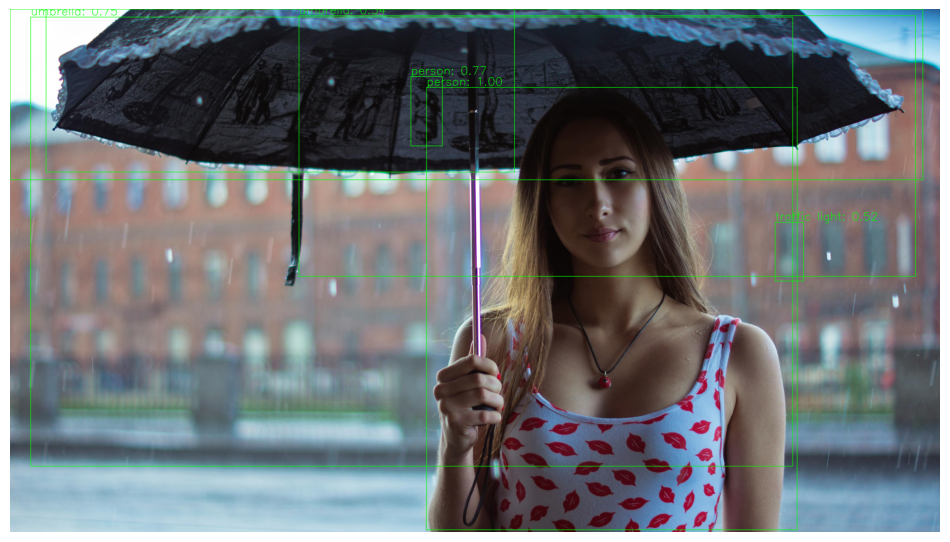

In [22]:
visualize_detections(image, boxes, scores, labels)

In [ ]:
import torch
import torchvision
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
import warnings
from ultralytics import YOLO
warnings.filterwarnings('ignore')

class Detector:
    """Базовый класс детектора объектов"""
    def __init__(self, model_type='frcnn', device=None, score_threshold=0.5):
        """
        Инициализация детектора
        
        Args:
            model_type: тип модели ('frcnn' или 'yolo')
            device: устройство для вычислений ('cuda' или 'cpu')
            score_threshold: порог уверенности для детекций
        """
        self.model_type = model_type.lower()
        self.score_threshold = score_threshold
        
        # Определяем устройство
        if device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
        
        print(f"Используется устройство: {self.device}")
        
        # Инициализируем выбранную модель
        if self.model_type == 'frcnn':
            self._init_frcnn()
        elif self.model_type == 'yolo':
            self._init_yolo()
        else:
            raise ValueError(f"Неизвестный тип модели: {model_type}. Поддерживаемые: 'frcnn', 'yolo'")
    
    def _init_frcnn(self):
        """Инициализация Faster R-CNN модели"""
        print("Загрузка Faster R-CNN модели...")
        self.model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
        self.model.to(self.device)
        self.model.eval()
        
        # COCO классы для Faster R-CNN
        self.class_names = [
            '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
            'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
            'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
            'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
            'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
            'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
            'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
            'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut',
            'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A',
            'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
            'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock',
            'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
        ]
        
    def _init_yolo(self):
        """Инициализация YOLO модели"""
        print("Загрузка YOLO модели...")
        model_path = Path('src/models/yolo26n.pt')
        if model_path.exists():
            print('Используем локальную модель')
            self.model = YOLO(model_path)
        else:
            print('Загружаем модель из интернета')
            self.model = YOLO('yolo26n.pt')
        
    
    def preprocess(self, frame):
        """
        Предобработка изображения
        
        Args:
            frame: изображение в формате PIL.Image, numpy.ndarray или путь к файлу
            
        Returns:
            torch.Tensor: тензор изображения
        """
        # Если передан путь к файлу
        if isinstance(frame, (str, Path)):
            frame = Image.open(frame)
        
        # Если передан numpy array (например, из OpenCV)
        if isinstance(frame, np.ndarray):
            # Конвертируем BGR в RGB
            if len(frame.shape) == 3 and frame.shape[2] == 3:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = Image.fromarray(frame)
        
        # Возвращаем PIL Image для дальнейшей обработки
        return frame
    
    def predict(self, frame):
        """
        Выполнение детекции объектов
        
        Args:
            frame: входное изображение
            
        Returns:
            tuple: (boxes, scores, labels, class_names)
        """
        # Предобработка изображения
        pil_image = self.preprocess(frame)
        
        if self.model_type == 'frcnn':
            return self._predict_frcnn(pil_image)
        elif self.model_type == 'yolo':
            return self._predict_yolo(pil_image)
    
    def _predict_frcnn(self, pil_image):
        """Предсказание с использованием Faster R-CNN"""
        # Преобразуем в тензор
        image_tensor = torchvision.transforms.functional.to_tensor(pil_image)
        image_tensor = image_tensor.to(self.device)
        
        # Выполняем предсказание
        with torch.no_grad():
            predictions = self.model([image_tensor])
        
        # Извлекаем результаты
        boxes = predictions[0]['boxes'].cpu().numpy()
        scores = predictions[0]['scores'].cpu().numpy()
        labels = predictions[0]['labels'].cpu().numpy()
        
        # Фильтруем по порогу уверенности
        keep = scores >= self.score_threshold
        boxes = boxes[keep]
        scores = scores[keep]
        labels = labels[keep]
        
        # Получаем имена классов
        
        class_names = [self.class_names[label] for label in labels]
        
        return boxes, scores, labels, class_names
    
    def _predict_yolo(self, pil_image):
        """Предсказание с использованием YOLO"""

        results = self.model(pil_image)  # Можно настроить размер
        
        # # Получаем результаты
        # predictions = results.xyxy[0]  # DataFrame с результатами
        
        # # Фильтруем по порогу уверенности
        # predictions = predictions[predictions['confidence'] >= self.score_threshold]
        
        # Извлекаем данные
        boxes = results[0].boxes.xyxy
        scores = [box.conf[0].item() for box in results[0].boxes]
        labels = [int(box.cls) for box in results[0].boxes]
        
        # Получаем имена классов
        class_names = [results[0].names[label] for label in labels]
        
        
        return boxes, scores, labels, class_names
    
    def visualize(self, frame, boxes, scores, labels, class_names, 
                  thickness=2, font_scale=0.5, color=(0, 255, 0)):
        """
        Визуализация результатов детекции
        
        Args:
            frame: исходное изображение
            boxes: координаты bounding box
            scores: уверенность детекций
            labels: метки классов
            class_names: имена классов
            thickness: толщина линий bounding box
            font_scale: масштаб шрифта
            color: цвет bounding box (BGR)
            
        Returns:
            numpy.ndarray: изображение с визуализацией детекций
        """
        # Если frame - PIL Image, конвертируем в numpy
        if isinstance(frame, Image.Image):
            frame = np.array(frame)
            # Конвертируем RGB в BGR для OpenCV
            if len(frame.shape) == 3 and frame.shape[2] == 3:
                frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        # Если frame - numpy array в RGB, конвертируем в BGR
        elif isinstance(frame, np.ndarray) and len(frame.shape) == 3 and frame.shape[2] == 3:
            # Проверяем, является ли изображение RGB (обычно YOLO возвращает RGB)
            frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        
        # Рисуем bounding boxes
        for box, score, label, class_name in zip(boxes, scores, labels, class_names):
            x1, y1, x2, y2 = box.astype(int)
            
            # Рисуем прямоугольник
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness)
            
            # Добавляем текст с классом и уверенностью
            text = f"{class_name}: {score:.2f}"
            
            # Получаем размер текста
            (text_width, text_height), baseline = cv2.getTextSize(
                text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness
            )
            
            # Рисуем фон для текста
            cv2.rectangle(frame, 
                         (x1, y1 - text_height - baseline - 5),
                         (x1 + text_width, y1),
                         color, -1)
            
            # Добавляем текст
            cv2.putText(frame, text, (x1, y1 - baseline - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 0, 0), thickness)
        
        return frame
    
    def process_video(self, video_path, output_path=None, show=True, fps=30):
        """
        Обработка видеофайла
        
        Args:
            video_path: путь к входному видео
            output_path: путь для сохранения результата (если None - не сохранять)
            show: показывать ли результат в реальном времени
            fps: FPS для выходного видео
        """
        cap = cv2.VideoCapture(video_path if isinstance(video_path, str) else str(video_path))
        
        if not cap.isOpened():
            print(f"Ошибка открытия видео: {video_path}")
            return
        
        # Получаем параметры видео
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        
        # Настраиваем видеозапись если нужно
        writer = None
        if output_path:
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
        
        frame_count = 0
        print(f"Начата обработка видео: {video_path}")
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            # Выполняем детекцию
            boxes, scores, labels, class_names = self.predict(frame)
            
            # Визуализируем результаты
            result_frame = self.visualize(frame, boxes, scores, labels, class_names)
            
            # Сохраняем если нужно
            if writer:
                writer.write(result_frame)
            
            # Показываем если нужно
            if show:
                cv2.imshow(f'Detector - {self.model_type.upper()}', result_frame)
                if cv2.waitKey(1) & 0xFF == ord('q'):
                    break
            
            frame_count += 1
            if frame_count % 30 == 0:
                print(f"Обработано кадров: {frame_count}")
        
        # Освобождаем ресурсы
        cap.release()
        if writer:
            writer.release()
        if show:
            cv2.destroyAllWindows()
        
        print(f"Обработка завершена. Всего кадров: {frame_count}")




In [13]:
detector = Detector(
    model_type='yolo',
    device='cuda',
    score_threshold=0.5
    )
    
    # 

Используется устройство: cuda
Загрузка YOLO модели...
Загружаем модель из интернета


In [14]:
image_path = 'pexels-vanyaoboleninov-237637.jpg'

image = Image.open(image_path).convert("RGB")

detector._predict_yolo(image)


0: 384x640 1 person, 1 umbrella, 29.8ms
Speed: 1.4ms preprocess, 29.8ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)


(tensor([[2191.3193,  385.6509, 4122.8877, 2735.7561],
         [ 205.9963,    0.0000, 4689.3901,  901.2889]]),
 [0.9208909273147583, 0.6706379652023315],
 [0, 25],
 {0: 'person',
  1: 'bicycle',
  2: 'car',
  3: 'motorcycle',
  4: 'airplane',
  5: 'bus',
  6: 'train',
  7: 'truck',
  8: 'boat',
  9: 'traffic light',
  10: 'fire hydrant',
  11: 'stop sign',
  12: 'parking meter',
  13: 'bench',
  14: 'bird',
  15: 'cat',
  16: 'dog',
  17: 'horse',
  18: 'sheep',
  19: 'cow',
  20: 'elephant',
  21: 'bear',
  22: 'zebra',
  23: 'giraffe',
  24: 'backpack',
  25: 'umbrella',
  26: 'handbag',
  27: 'tie',
  28: 'suitcase',
  29: 'frisbee',
  30: 'skis',
  31: 'snowboard',
  32: 'sports ball',
  33: 'kite',
  34: 'baseball bat',
  35: 'baseball glove',
  36: 'skateboard',
  37: 'surfboard',
  38: 'tennis racket',
  39: 'bottle',
  40: 'wine glass',
  41: 'cup',
  42: 'fork',
  43: 'knife',
  44: 'spoon',
  45: 'bowl',
  46: 'banana',
  47: 'apple',
  48: 'sandwich',
  49: 'orange',
  50: 